In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.rcParams["figure.figsize"] = (10, 5)

In [17]:
csv_path = "archive/Data.csv"

chunksize = 5000        # small chunk to protect RAM
target_rows = 1000      # final sample size

samples = []
collected = 0

for chunk in pd.read_csv(csv_path, chunksize=chunksize, low_memory=True):
    
    # randomly sample from each chunk
    take = min(200, len(chunk), target_rows - collected)
    samples.append(chunk.sample(n=take, random_state=42))
    
    collected += take
    
    if collected >= target_rows:
        break

df = pd.concat(samples, ignore_index=True)

print("Shape:", df.shape)
df.head()

Shape: (1000, 57)


,time,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,...,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,label
0,2000-01-10 00:03:00,0.0,4.0,2,0.24957,3652.0,4491.8,9.3392,26.804,42.441,...,24.737,61.585,22.153,40.240,36.137,45.280,47.332,40.196,19.880,0.0
1,2000-01-16 04:18:00,0.0,6.0,87,0.21398,3637.9,4512.0,9.4458,26.905,42.098,...,20.974,60.805,21.875,42.198,35.490,49.830,50.286,40.330,20.087,0.0
2,2000-01-16 07:39:00,0.0,6.0,154,0.31875,3634.2,4448.7,9.2233,27.161,41.979,...,31.766,62.929,21.417,39.534,42.118,47.927,47.924,40.808,19.438,0.0
3,2000-01-07 02:45:00,0.0,3.0,56,0.21925,3616.0,4564.9,9.1980,26.689,41.984,...,21.771,61.193,22.469,37.936,28.444,43.980,44.813,41.929,19.462,0.0
4,2000-01-04 10:15:00,0.0,2.0,206,0.25746,3642.2,4489.6,9.3190,26.847,42.382,...,25.593,63.276,22.312,38.655,39.957,47.366,43.854,41.577,17.125,0.0


In [18]:
print("Shape:", df.shape)
df.info()


Shape: (1000, 57)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 57 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           1000 non-null   object 
 1   faultNumber    1000 non-null   float64
 2   simulationRun  1000 non-null   float64
 3   sample         1000 non-null   int64  
 4   xmeas_1        1000 non-null   float64
 5   xmeas_2        1000 non-null   float64
 6   xmeas_3        1000 non-null   float64
 7   xmeas_4        1000 non-null   float64
 8   xmeas_5        1000 non-null   float64
 9   xmeas_6        1000 non-null   float64
 10  xmeas_7        1000 non-null   float64
 11  xmeas_8        1000 non-null   float64
 12  xmeas_9        1000 non-null   float64
 13  xmeas_10       1000 non-null   float64
 14  xmeas_11       1000 non-null   float64
 15  xmeas_12       1000 non-null   float64
 16  xmeas_13       1000 non-null   float64
 17  xmeas_14       1000 non-null   floa

In [19]:
#  Missing values and duplicates check

print("Dataset Shape:", df.shape)

# Missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nTotal Missing Values:", df.isna().sum().sum())

if len(missing) == 0:
    print("✅ No missing values found.")
else:
    print("\nColumns with missing values:")
    print(missing)

# Duplicate rows
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)

Dataset Shape: (1000, 57)

Total Missing Values: 0
✅ No missing values found.

Duplicate rows: 0


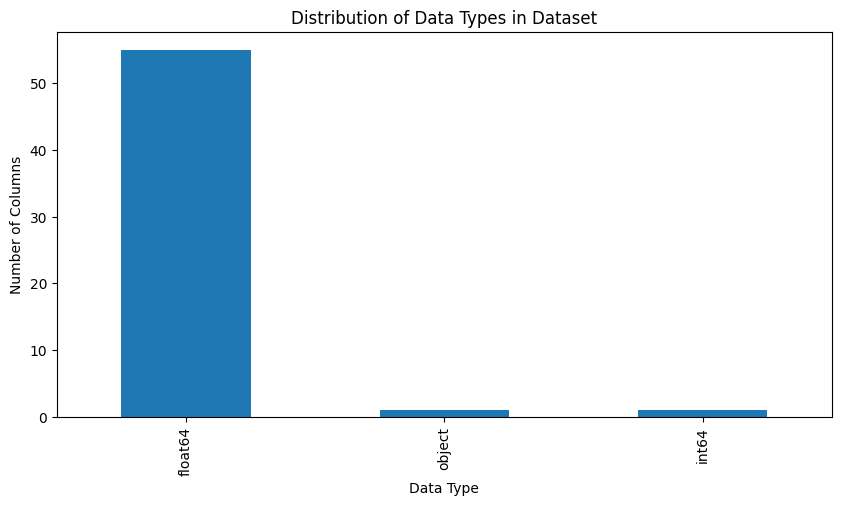

In [20]:
# CELL 5 — Data type distribution

dtype_counts = df.dtypes.value_counts()

plt.figure()
dtype_counts.plot(kind='bar')
plt.title("Distribution of Data Types in Dataset")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")
plt.show()

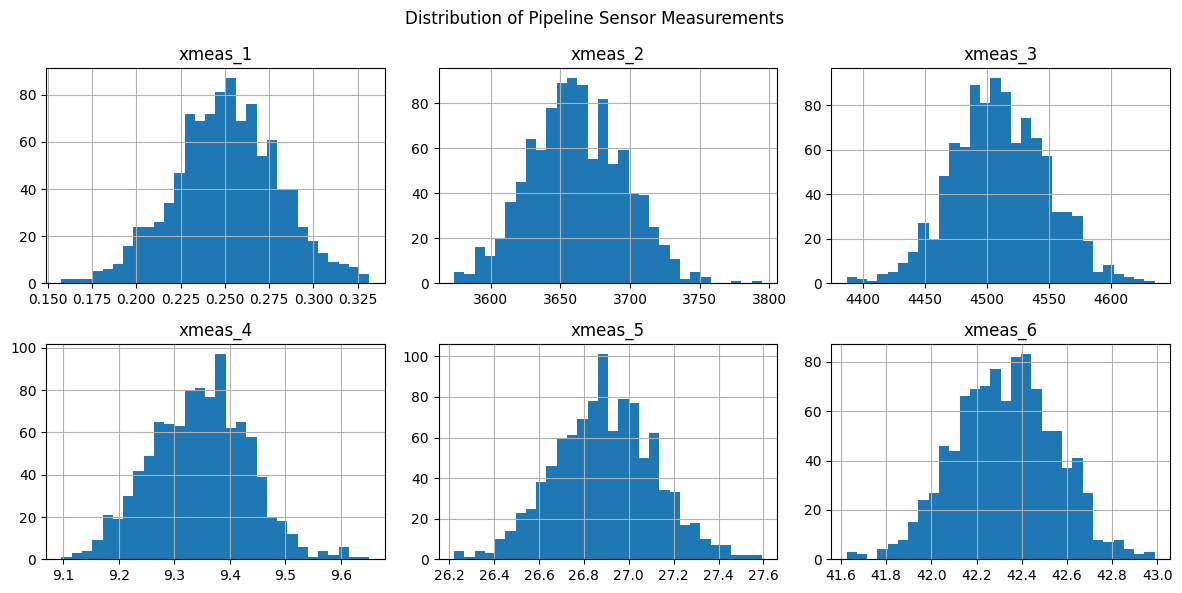

In [21]:
#  Histograms of sensor measurements

sensor_cols = [c for c in df.columns if c.startswith("xmeas")]

df[sensor_cols[:6]].hist(bins=30, layout=(2,3), figsize=(12,6))

plt.suptitle("Distribution of Pipeline Sensor Measurements")
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

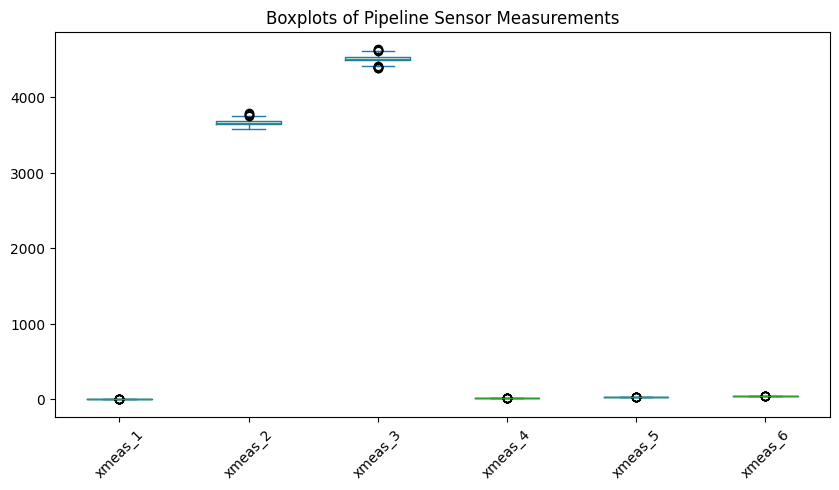

In [22]:
# select only measurement sensors
sensor_cols = [c for c in df.columns if c.startswith("xmeas")]

plt.figure(figsize=(14,6))
df[sensor_cols[:6]].plot(kind='box')  # first 6 sensors for readability

plt.title("Boxplots of Pipeline Sensor Measurements")
plt.xticks(rotation=45)
plt.show()

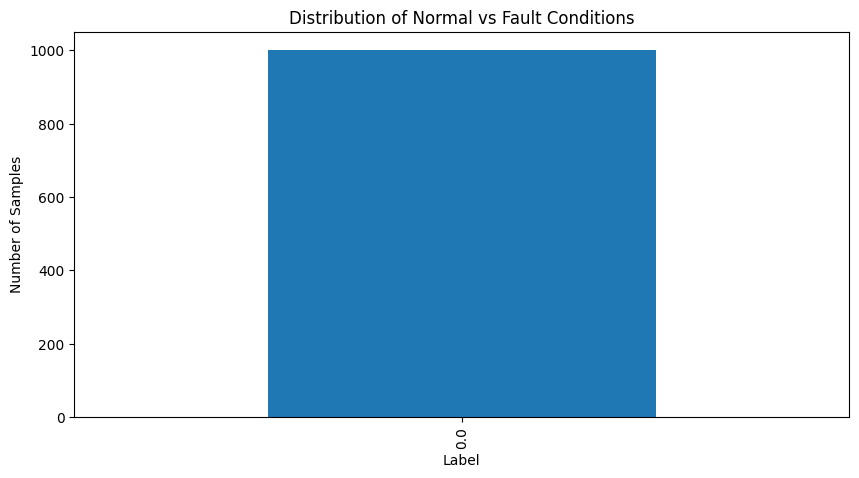

In [23]:
# CELL 8 — Label distribution

plt.figure()

df['label'].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Normal vs Fault Conditions")
plt.xlabel("Label")
plt.ylabel("Number of Samples")

plt.show()

In [24]:
df['label'].value_counts()

label
0.0    1000
Name: count, dtype: int64

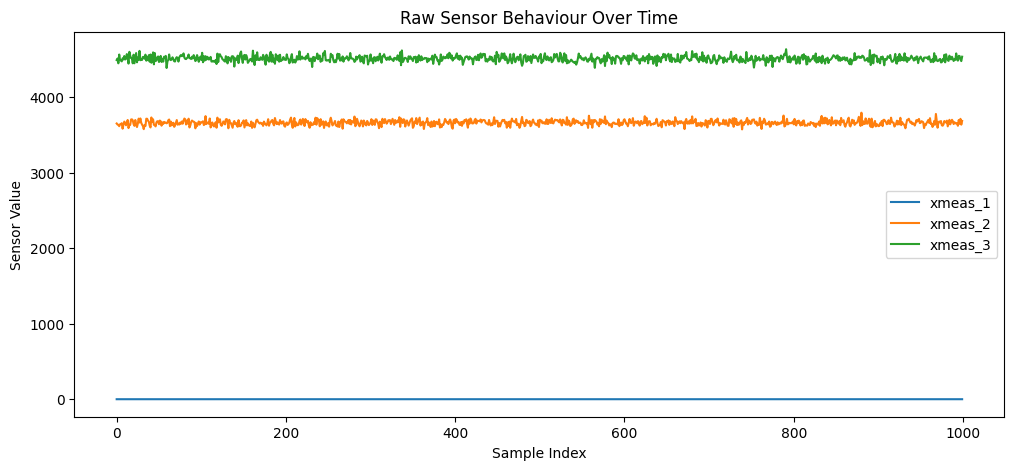

In [26]:
#  — Raw sensor behaviour over time

sensor_cols = [c for c in df.columns if c.startswith("xmeas")]

plt.figure(figsize=(12,5))

for col in sensor_cols[:3]:   # plot only 3 sensors to keep readable
    plt.plot(df[col], label=col)

plt.title("Raw Sensor Behaviour Over Time")
plt.xlabel("Sample Index")
plt.ylabel("Sensor Value")
plt.legend()

plt.show()

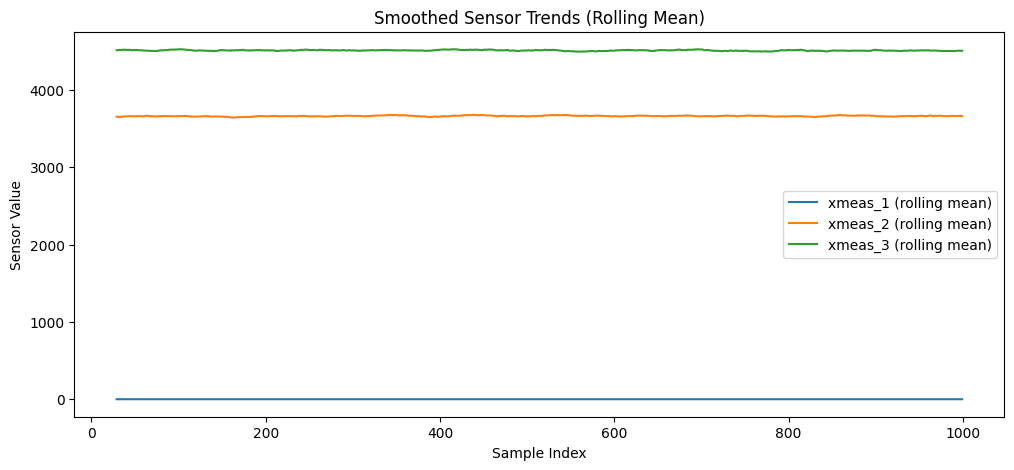

In [25]:
# — Rolling mean (trend smoothing)

sensor_cols = [c for c in df.columns if c.startswith("xmeas")]

window = 30   # smoothing window

plt.figure(figsize=(12,5))

for col in sensor_cols[:3]:
    smooth = df[col].rolling(window=window).mean()
    plt.plot(smooth, label=f"{col} (rolling mean)")

plt.title("Smoothed Sensor Trends (Rolling Mean)")
plt.xlabel("Sample Index")
plt.ylabel("Sensor Value")
plt.legend()

plt.show()

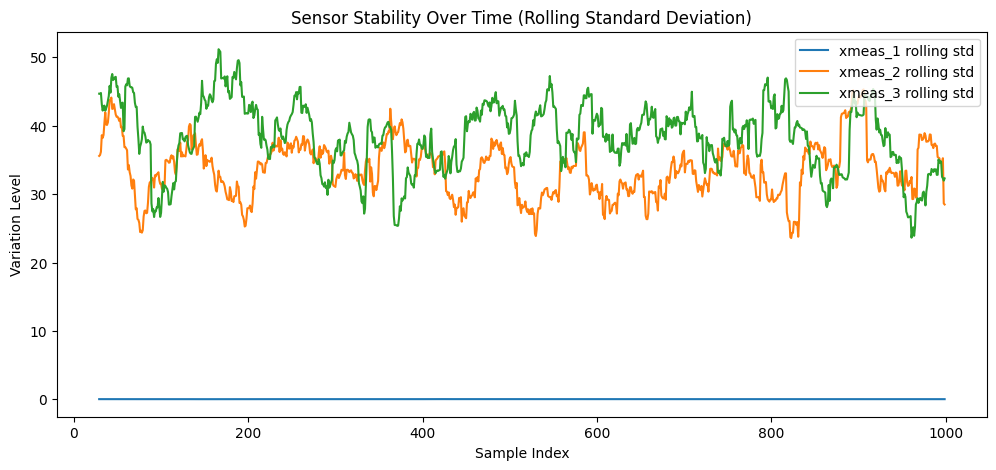

In [27]:
# Rolling Standard Deviation (detect instability)

sensor_cols = [c for c in df.columns if c.startswith("xmeas")]

window = 30

plt.figure(figsize=(12,5))

for col in sensor_cols[:3]:
    rolling_std = df[col].rolling(window=window).std()
    plt.plot(rolling_std, label=f"{col} rolling std")

plt.title("Sensor Stability Over Time (Rolling Standard Deviation)")
plt.xlabel("Sample Index")
plt.ylabel("Variation Level")
plt.legend()

plt.show()